
<img align="right" width="125" src="https://www.ou.nl/documents/40554/3255217/Logo_OU.jpg"/>

<br>


<center> <font size ="6" color='red'> AI for Prescriptive Analysis </font></center>
<br> 
<center> <font size ="5" color='red'> Discrete Event Simulation in Python</font></center>
<br> 


--------------------------


In [1]:
from Controller import*
mycontroller = Controller()
mytab = mycontroller.GetDashBoard(); milptab = mycontroller.GenerateMILPTab()
tab_set = widgets.Tab([mytab,milptab])
tab_set.set_title(0,'Main');tab_set.set_title(1,'MILP'); tab_set

Start day:  2026-08-22  weekday:  5  day:  Saturday , TimeLimit:  None
Controller: Generating dashboard
Visual Manager: Generating dashboard


Item batches: 116
+++++++++++++++++++++++++++++++++++++++++++++++++++++++++
Location:  CentralBuffer_Location
+++++++++++++++++++++++++++++++++++++++++++++++++++++++++
Location:  Trailer_60
+++++++++++++++++++++++++++++++++++++++++++++++++++++++++
Location:  Trailer_61
+++++++++++++++++++++++++++++++++++++++++++++++++++++++++
Location:  Trailer_62
+++++++++++++++++++++++++++++++++++++++++++++++++++++++++
Location:  Trailer_63
+++++++++++++++++++++++++++++++++++++++++++++++++++++++++
Location:  BW_(BKW_01)_Location
Machine Setup 124 BW_(BKW_01)_Location 3505
Machine Loading 795 BW_(BKW_01)_Location 3619
Machine Processing 840 BW_(BKW_01)_Location 3668
Machine Unloading 854 BW_(BKW_01)_Location 3803
Machine Setup 125 BW_(BKW_01)_Location 3805
Machine Loading 886 BW_(BKW_01)_Location 3847
Machine Processing 901 BW_(BKW_01)_Location 4085
Machine Unloading 919 BW_(BKW_01)_Location 4877
Machine Setup 126 BW_(BKW_01)_Location 4879
Machine Loading 949 BW_(BKW_01)_Location 4973
Machine Processi

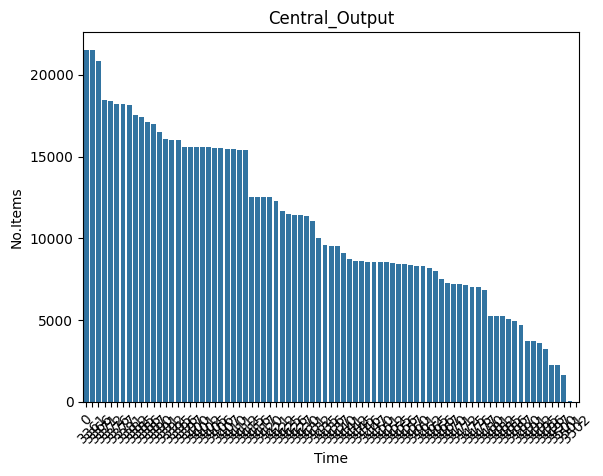

,BufferName,Time,No.Items
0,Central_Output,0,21526
1,Central_Output,3361,21509
2,Central_Output,3366,20871
3,Central_Output,3371,18450
4,Central_Output,3372,18426
...,...,...,...
76,Central_Output,3496,2265
77,Central_Output,3497,2230
78,Central_Output,3500,1662
79,Central_Output,3501,62


______________________________


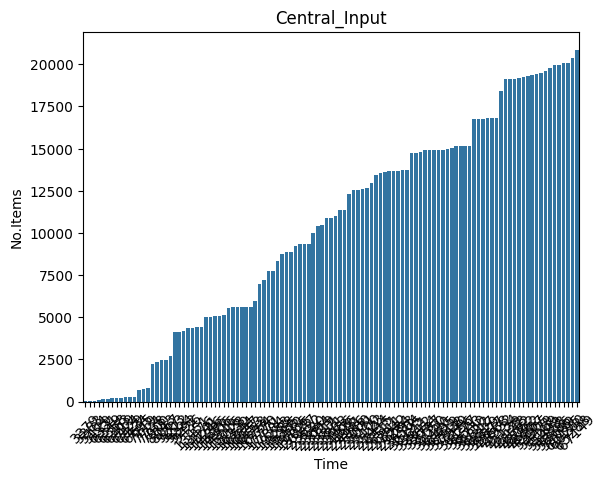

,BufferName,Time,No.Items
0,Central_Input,3379,24
1,Central_Input,3383,44
2,Central_Input,5104,61
3,Central_Input,5129,65
4,Central_Input,6331,157
...,...,...,...
95,Central_Input,45148,19143
96,Central_Input,46592,19158
97,Central_Input,48062,19204
98,Central_Input,48862,19224


______________________________


In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

exec_df = pd.read_csv("EventExecutionData.csv")

diagnose = True

print("Item batches: "+str(len(exec_df["Items"].unique())))

for batch in exec_df["Items"].unique():
    if pd.isnull(batch):
        continue
    sub_df = exec_df[exec_df["Items"] == batch]
    sub_df = sub_df.sort_values(['SimTime'])
    start = sub_df.iloc[0, sub_df.columns.get_loc('Location')]
    end = sub_df.iloc[len(sub_df)-1, sub_df.columns.get_loc('Location')]

    #if start != end:
    #    display(sub_df)
    
    #    print("______________________________")
    

#process_df = exec_df[exec_df["EventName"] == "Machine Processing"]

for myloc in exec_df["Location"].unique():
    print("+++++++++++++++++++++++++++++++++++++++++++++++++++++++++")
    print("Location: ",myloc)
    sub_df = exec_df[exec_df["Location"] == myloc]
    sub_df  = sub_df[(sub_df["EventName"] == "Machine Setup") | (sub_df["EventName"] =="Machine Loading") | (sub_df["EventName"] == "Machine Processing") | (sub_df["EventName"] == "Machine Unloading")]
    if diagnose and len(sub_df)  > 0:
        for i,r in sub_df.iterrows():
            print(r["EventName"],r["EventID"],r["Location"],r["SimTime"])
        
        #display(sub_df)

    


print("~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~")
exec_df = pd.read_csv("BufferData.csv")

for buff in exec_df["BufferName"].unique():
    sub_df = exec_df[exec_df["BufferName"] == buff]
    agg_df = sub_df.groupby(['BufferName','Time'])['No.Items'].max().reset_index()
    agg_df = agg_df.rename(columns={agg_df.columns[-1]: "No.Items"})

    if buff in ["Central_Output","Central_Input"]:
        sns.barplot(agg_df, x="Time", y="No.Items", legend=False).set_title(buff)
        plt.xticks(rotation=45)
        plt.show()
        
        display(agg_df.head(100))
        print("______________________________")    

In [ ]:
import pandas as pd

location_df = pd.read_csv("LocationData.csv")

for entity in location_df["EntityID"].unique():
    sub_df = location_df[location_df["EntityID"] == entity]
    display(sub_df)
    print("______________________________")
    

In [ ]:
# Importing the matplotlib.pyplot
import matplotlib.pyplot as plt

# Declaring a figure "gnt"
fig, gnt = plt.subplots()

# Setting Y-axis limits
gnt.set_ylim(0, 50)

# Setting X-axis limits
gnt.set_xlim(0, 160)

# Setting labels for x-axis and y-axis
gnt.set_xlabel('seconds since start')
gnt.set_ylabel('Processor')

# Setting ticks on y-axis
gnt.set_yticks([15, 25, 35])
# Labelling tickes of y-axis
gnt.set_yticklabels(['1', '2', '3'])

# Setting graph attribute
gnt.grid(True)

# Declaring a bar in schedule
gnt.broken_barh([(40, 50)], (30, 9), facecolors =('tab:orange'))

# Declaring multiple bars in at same level and same width
gnt.broken_barh([(110, 10), (150, 10)], (10, 9),
                         facecolors ='tab:blue')

gnt.broken_barh([(10, 50), (100, 20), (130, 10)], (20, 9),
                                  facecolors =('tab:red'))
